# Ensembles, MLflow e Explicabilidade — Projeto Lupa (Módulo 7)

1. MLflow Tracking configurado, todo experimento registrado
2. XGBoost, LightGBM, CatBoost com tuning via Optuna
3. Melhor modelo promovido no Model Registry
4. SHAP - explicações globais e locais (3 despesas reais)
5. Calibração de threshold pela curva PR

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import mlflow
import optuna
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score

from src.preprocessing import (
    carregar_dados, construir_pipeline_preprocessamento, criar_target,
    get_engine, split_out_of_time,
)

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("lupa-houve-glosa")

engine = get_engine()
df = criar_target(carregar_dados(engine))
treino, teste = split_out_of_time(df, ano_corte=2026, mes_corte=4)

pipeline_prep = construir_pipeline_preprocessamento()
X_treino = pipeline_prep.fit_transform(treino)
X_teste = pipeline_prep.transform(teste)
y_treino = treino["houve_glosa"].values
y_teste = teste["houve_glosa"].values

print(f"Treino: {X_treino.shape} | Teste: {X_teste.shape}")
print(f"Proporção de glosa - treino: {y_treino.mean()*100:.2f}% | teste: {y_teste.mean()*100:.2f}%")

Treino: (585372, 69) | Teste: (55146, 69)
Proporção de glosa - treino: 4.82% | teste: 4.51%


## Validação dentro do treino (nunca tocar no teste durante o tuning)

O Optuna precisa de um conjunto pra avaliar cada tentativa de hiperparâmetro. Usar o teste real pra isso seria "espiar" o teste - vazamento por outro caminho (overfitting na escolha do hiperparâmetro). Solução: outro corte cronológico *dentro* do treino.

In [2]:
treino_fit, treino_val = split_out_of_time(treino, ano_corte=2026, mes_corte=1)
print(f"Treino-fit: {len(treino_fit)} | Treino-val: {len(treino_val)}")

pipeline_tuning = construir_pipeline_preprocessamento()
X_fit = pipeline_tuning.fit_transform(treino_fit)
X_val = pipeline_tuning.transform(treino_val)
y_fit = treino_fit["houve_glosa"].values
y_val = treino_val["houve_glosa"].values

peso_classe = (y_fit == 0).sum() / (y_fit == 1).sum()
print(f"Peso da classe positiva (scale_pos_weight): {peso_classe:.2f}")

Treino-fit: 541991 | Treino-val: 43381


Peso da classe positiva (scale_pos_weight): 19.85


In [3]:
def objetivo_xgboost(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "scale_pos_weight": peso_classe,
        "eval_metric": "aucpr",
        "random_state": 42,
    }
    with mlflow.start_run(run_name=f"xgboost_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        modelo = xgb.XGBClassifier(**params)
        modelo.fit(X_fit, y_fit)
        score = modelo.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, score)
        mlflow.log_metric("pr_auc_val", pr_auc)
    return pr_auc


def objetivo_lightgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "is_unbalance": True,
        "random_state": 42,
        "verbosity": -1,
    }
    with mlflow.start_run(run_name=f"lightgbm_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        modelo = lgb.LGBMClassifier(**params)
        modelo.fit(X_fit, y_fit)
        score = modelo.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, score)
        mlflow.log_metric("pr_auc_val", pr_auc)
    return pr_auc


def objetivo_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 50, 300),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "auto_class_weights": "Balanced",
        "random_state": 42,
        "verbose": False,
    }
    with mlflow.start_run(run_name=f"catboost_trial_{trial.number}", nested=True):
        mlflow.log_params(params)
        modelo = CatBoostClassifier(**params)
        modelo.fit(X_fit, y_fit)
        score = modelo.predict_proba(X_val)[:, 1]
        pr_auc = average_precision_score(y_val, score)
        mlflow.log_metric("pr_auc_val", pr_auc)
    return pr_auc

In [4]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 6  # 3 modelos x 6 tentativas = 18 runs no MLflow

estudos = {}
for nome_modelo, objetivo in [
    ("xgboost", objetivo_xgboost),
    ("lightgbm", objetivo_lightgbm),
    ("catboost", objetivo_catboost),
]:
    with mlflow.start_run(run_name=f"{nome_modelo}_tuning"):
        estudo = optuna.create_study(direction="maximize")
        estudo.optimize(objetivo, n_trials=N_TRIALS)
        mlflow.log_metric("melhor_pr_auc_val", estudo.best_value)
        mlflow.log_params({f"melhor_{k}": v for k, v in estudo.best_params.items()})
    estudos[nome_modelo] = estudo
    print(f"{nome_modelo}: melhor PR-AUC (val) = {estudo.best_value:.4f} | params = {estudo.best_params}")

xgboost: melhor PR-AUC (val) = 0.4444 | params = {'n_estimators': 163, 'max_depth': 7, 'learning_rate': 0.08693383523712893, 'subsample': 0.9439125305467619}


lightgbm: melhor PR-AUC (val) = 0.4669 | params = {'n_estimators': 276, 'max_depth': 5, 'learning_rate': 0.20465549145606213, 'num_leaves': 50}


catboost: melhor PR-AUC (val) = 0.4544 | params = {'iterations': 270, 'depth': 6, 'learning_rate': 0.18556058510386697}


## Modelo final: LightGBM (venceu na validação), treinado no treino completo e avaliado no teste real

In [5]:
melhores_params = estudos["lightgbm"].best_params
melhores_params.update({"is_unbalance": True, "random_state": 42, "verbosity": -1})

with mlflow.start_run(run_name="lightgbm_final") as run:
    modelo_final = lgb.LGBMClassifier(**melhores_params)
    modelo_final.fit(X_treino, y_treino)

    score_teste = modelo_final.predict_proba(X_teste)[:, 1]
    pred_teste = modelo_final.predict(X_teste)

    pr_auc_teste = average_precision_score(y_teste, score_teste)
    auc_roc_teste = roc_auc_score(y_teste, score_teste)

    mlflow.log_params(melhores_params)
    mlflow.log_metric("pr_auc_teste", pr_auc_teste)
    mlflow.log_metric("auc_roc_teste", auc_roc_teste)

    assinatura = mlflow.models.infer_signature(X_treino, score_teste)
    mlflow.lightgbm.log_model(
        modelo_final, name="modelo",
        registered_model_name="lupa-houve-glosa-lightgbm",
        signature=assinatura,
    )
    run_id_final = run.info.run_id

print(f"PR-AUC (teste real): {pr_auc_teste:.4f}")
print(f"AUC-ROC (teste real): {auc_roc_teste:.4f}")
print(f"Run ID: {run_id_final}")

2026/08/03 16:29:16 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


PR-AUC (teste real): 0.4121
AUC-ROC (teste real): 0.8938
Run ID: 31d80b48bad54de0aa099d687470f3f0


Successfully registered model 'lupa-houve-glosa-lightgbm'.
Created version '1' of model 'lupa-houve-glosa-lightgbm'.


## SHAP — explicação global e local

Nunca exibir um score sozinho (princípio de responsabilidade do projeto). SHAP mostra, pra cada despesa, o quanto cada feature empurrou a previsão pra cima ou pra baixo.

C:\Users\PDCASE\Desktop\Projeto Lupa\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


C:\Users\PDCASE\AppData\Local\Temp\ipykernel_26964\271238840.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


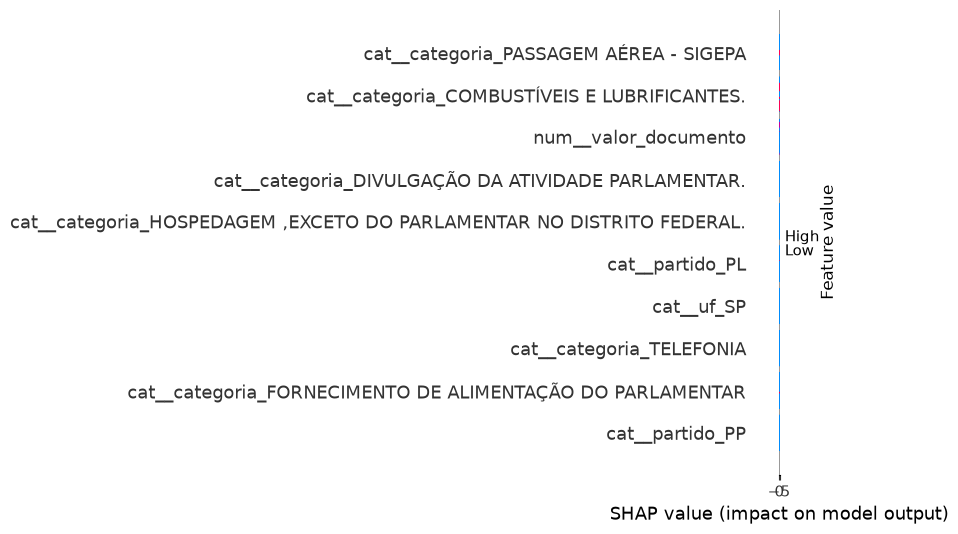

In [6]:
import shap

nomes_features = pipeline_prep.get_feature_names_out()

explicador = shap.TreeExplainer(modelo_final)

# amostra do teste, pra explicação global não ficar lenta demais
indices_amostra = np.random.RandomState(42).choice(X_teste.shape[0], size=2000, replace=False)
X_teste_denso_amostra = np.asarray(X_teste[indices_amostra].todense()) if hasattr(X_teste, "todense") else X_teste[indices_amostra]

valores_shap = explicador.shap_values(X_teste_denso_amostra)

import matplotlib.pyplot as plt
shap.summary_plot(valores_shap, X_teste_denso_amostra, feature_names=nomes_features, show=False, max_display=10)
plt.tight_layout()
plt.show()

In [7]:
# 3 despesas reais: 1 acerto (glosa real, score alto), 1 falso positivo (sem glosa, score alto),
# 1 acerto de "sem glosa" com confiança alta
score_teste_completo = modelo_final.predict_proba(X_teste)[:, 1]

idx_acerto_glosa = np.where((y_teste == 1))[0][np.argsort(-score_teste_completo[y_teste == 1])[0]]
idx_falso_positivo = np.where((y_teste == 0))[0][np.argsort(-score_teste_completo[y_teste == 0])[0]]
idx_acerto_sem_glosa = np.where((y_teste == 0))[0][np.argsort(score_teste_completo[y_teste == 0])[0]]

casos = {
    "Acerto - glosa real detectada": idx_acerto_glosa,
    "Falso positivo - sinalizado sem glosa real": idx_falso_positivo,
    "Acerto - sem glosa, alta confiança": idx_acerto_sem_glosa,
}

teste_reset = teste.reset_index(drop=True)

for titulo, idx in casos.items():
    linha_original = teste_reset.iloc[idx]
    X_linha = X_teste[idx : idx + 1]
    X_linha_denso = np.asarray(X_linha.todense()) if hasattr(X_linha, "todense") else X_linha
    shap_linha = explicador.shap_values(X_linha_denso)[0]

    top_idx = np.argsort(-np.abs(shap_linha))[:3]
    print(f"\n=== {titulo} ===")
    print(f"Categoria: {linha_original['categoria']} | Partido: {linha_original['partido']} | UF: {linha_original['uf']}")
    print(f"Valor: R$ {linha_original['valor_documento']:.2f} | Score do modelo: {score_teste_completo[idx]:.3f} | Glosa real: {'sim' if y_teste[idx] else 'não'}")
    print("Principais fatores:")
    for i in top_idx:
        direcao = "aumentou" if shap_linha[i] > 0 else "diminuiu"
        print(f"  - {nomes_features[i]} {direcao} a chance de glosa (impacto {shap_linha[i]:+.3f})")


=== Acerto - glosa real detectada ===
Categoria: LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES | Partido: PL | UF: PR
Valor: R$ 1111.85 | Score do modelo: 0.992 | Glosa real: sim
Principais fatores:
  - cat__categoria_PASSAGEM AÉREA - SIGEPA aumentou a chance de glosa (impacto +2.068)
  - num__valor_documento aumentou a chance de glosa (impacto +1.931)
  - cat__categoria_LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES aumentou a chance de glosa (impacto +1.317)

=== Falso positivo - sinalizado sem glosa real ===
Categoria: LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES | Partido: REPUBLICANOS | UF: PB
Valor: R$ 17500.00 | Score do modelo: 0.985 | Glosa real: não
Principais fatores:
  - num__valor_documento aumentou a chance de glosa (impacto +2.616)
  - cat__categoria_PASSAGEM AÉREA - SIGEPA aumentou a chance de glosa (impacto +2.007)
  - cat__partido_REPUBLICANOS aumentou a chance de glosa (impacto +1.215)

=== Acerto - sem glosa, alta confiança ===
Categoria: PASSAGEM AÉREA - SIGEPA | 

C:\Users\PDCASE\Desktop\Projeto Lupa\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Calibração de threshold pela curva PR (não usar 0.5 padrão)

In [8]:
from sklearn.metrics import precision_recall_curve

CUSTO_FALSO_POSITIVO = 50
CUSTO_FALSO_NEGATIVO = 500

precisoes, recalls, thresholds = precision_recall_curve(y_teste, score_teste_completo)

custos = []
for i, th in enumerate(thresholds):
    pred_th = (score_teste_completo >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_teste, pred_th).ravel()
    custo = fp * CUSTO_FALSO_POSITIVO + fn * CUSTO_FALSO_NEGATIVO
    custos.append(custo)

custos = np.array(custos)
melhor_i = np.argmin(custos)
melhor_threshold = thresholds[melhor_i]

# custo do threshold padrão 0.5, pra comparação
pred_05 = (score_teste_completo >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_teste, pred_05).ravel()
custo_05 = fp * CUSTO_FALSO_POSITIVO + fn * CUSTO_FALSO_NEGATIVO

print(f"Threshold padrão (0.5): custo = R$ {custo_05:,.2f}")
print(f"Threshold ótimo ({melhor_threshold:.3f}): custo = R$ {custos[melhor_i]:,.2f}")
print(f"Precision no threshold ótimo: {precisoes[melhor_i]:.3f} | Recall: {recalls[melhor_i]:.3f}")
print(f"Economia: R$ {custo_05 - custos[melhor_i]:,.2f}")

Threshold padrão (0.5): custo = R$ 676,950.00
Threshold ótimo (0.673): custo = R$ 598,950.00
Precision no threshold ótimo: 0.268 | Recall: 0.713
Economia: R$ 78,000.00


## Calibração de probabilidade (Brier score)

Um modelo pode ranquear bem (boa PR-AUC) mas ter probabilidades "cruas" mal calibradas (ex.: dizer 90% quando a chance real é 60%). Calibração isotônica ajusta isso, usando o conjunto de validação (nunca o teste).

In [9]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

brier_antes = brier_score_loss(y_teste, score_teste_completo)

calibrador = CalibratedClassifierCV(FrozenEstimator(modelo_final), method="isotonic")
calibrador.fit(X_val, y_val)  # calibra com o conjunto de validação, nunca com o teste
score_calibrado = calibrador.predict_proba(X_teste)[:, 1]

brier_depois = brier_score_loss(y_teste, score_calibrado)

print(f"Brier score antes da calibração: {brier_antes:.4f}")
print(f"Brier score depois da calibração (isotônica): {brier_depois:.4f}")
print(f"Melhora: {(brier_antes - brier_depois) / brier_antes * 100:.1f}%")

with mlflow.start_run(run_name="lightgbm_calibrado", nested=False):
    mlflow.log_metric("brier_antes", brier_antes)
    mlflow.log_metric("brier_depois", brier_depois)
    mlflow.log_metric("threshold_otimo", melhor_threshold)

Brier score antes da calibração: 0.1131
Brier score depois da calibração (isotônica): 0.0330
Melhora: 70.8%
